# Fraud Detection — Isolation Forest & XGBoost

## 1. Data Loading and Exploration

In [27]:
import pandas as pd
dataset = pd.read_csv("dataset/transactions.csv")
dataset.head()

,customer_id,transaction_id,card_id,amount,city,country,timestamp,payment_method,device_type,amount_ratio,...,payment_method_changed,city_changed,country_changed,out_hours,amount_abnormal,is_fraud,usual_device,usual_city,usual_country,usual_payment_method
0,873,78a2947f-68db-4a77-a22c-3c95d741861d,4111975045213882,421.364237,Nador,Maroc,2026-08-29T13:39:48,credit_card,Mobile,1.273394,...,1,0,0,0,0,0,Mobile,Nador,Maroc,bank_transfer
1,980,99c7f36c-6f73-4168-bd6f-a5b029c44d57,3502507866594279,305.885672,Marrakech,Maroc,2026-08-29T13:20:18,bank_transfer,POS Terminal,0.831366,...,1,0,0,0,0,0,POS Terminal,Marrakech,Maroc,paypal
2,910,0fc99beb-6ad5-40d6-afbd-1c7b6bf037b6,60498325129,268.192745,Essaouira,Maroc,2026-08-29T11:04:27,credit_card,Laptop,0.791901,...,0,0,0,0,0,0,POS Terminal,Essaouira,Maroc,credit_card
3,81,ca3cef90-2509-4c10-a90c-2796f1a32ebf,2272082861702087,392.743516,Béni Mellal,Maroc,2026-08-29T11:01:09,bank_transfer,POS Terminal,1.072887,...,0,0,0,0,0,0,POS Terminal,Béni Mellal,Maroc,bank_transfer
4,353,6b218a43-66a0-4fb5-b8c8-4b1efdb28cf3,5311488056949480,465.212640,Al Hoceïma,Maroc,2026-08-29T05:43:18,paypal,Mobile,1.044645,...,0,0,0,1,0,0,Mobile,Al Hoceïma,Maroc,paypal


In [28]:
dataset.shape

(100000, 21)

In [29]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   customer_id             100000 non-null  int64  
 1   transaction_id          100000 non-null  str    
 2   card_id                 100000 non-null  int64  
 3   amount                  100000 non-null  float64
 4   city                    100000 non-null  str    
 5   country                 100000 non-null  str    
 6   timestamp               100000 non-null  str    
 7   payment_method          100000 non-null  str    
 8   device_type             100000 non-null  str    
 9   amount_ratio            100000 non-null  float64
 10  device_changed          100000 non-null  int64  
 11  payment_method_changed  100000 non-null  int64  
 12  city_changed            100000 non-null  int64  
 13  country_changed         100000 non-null  int64  
 14  out_hours               100000 n

In [30]:
dataset.describe()

,customer_id,card_id,amount,amount_ratio,device_changed,payment_method_changed,city_changed,country_changed,out_hours,amount_abnormal,is_fraud
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000
mean,498.640530,3.730182e+17,529.671633,1.413713,0.175630,0.219640,0.127270,0.128470,0.17132,0.071650,0.049560
std,288.552675,1.239627e+18,582.362890,1.526611,0.380507,0.414005,0.333277,0.334614,0.37679,0.257909,0.217035
min,1.000000,6.040012e+10,139.178326,0.430250,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,249.000000,1.800000e+14,317.811797,0.884859,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,498.000000,3.512221e+15,379.993633,1.019878,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
75%,748.000000,4.614943e+15,460.855022,1.189354,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
max,1000.000000,4.999975e+18,6466.116964,9.999968,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


### 1.1 Outlier Detection (IQR method)

In [31]:
# amount outliers detection 
Q1 = dataset['amount'].quantile(0.25)
Q3 = dataset['amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = dataset[(dataset['amount'] < lower) | (dataset['amount'] > upper)]
print(f"{len(outliers)} outliers sur {len(dataset)} lignes")

8016 outliers sur 100000 lignes


In [32]:
# amount outliers detection 
Q1 = dataset['amount_ratio'].quantile(0.25)
Q3 = dataset['amount_ratio'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = dataset[(dataset['amount_ratio'] < lower) | (dataset['amount_ratio'] > upper)]
print(f"{len(outliers)} outliers sur {len(dataset)} lignes")

7760 outliers sur 100000 lignes


### 1.2 Exploratory Data Analysis (EDA)

Répartition is_fraud :
is_fraud
0    0.95044
1    0.04956
Name: proportion, dtype: float64

Statistiques descriptives - amount :
count    100000.000000
mean        529.671633
std         582.362890
min         139.178326
25%         317.811797
50%         379.993633
75%         460.855022
max        6466.116964
Name: amount, dtype: float64

Statistiques descriptives - amount_ratio :
count    100000.000000
mean          1.413713
std           1.526611
min           0.430250
25%           0.884859
50%           1.019878
75%           1.189354
max           9.999968
Name: amount_ratio, dtype: float64



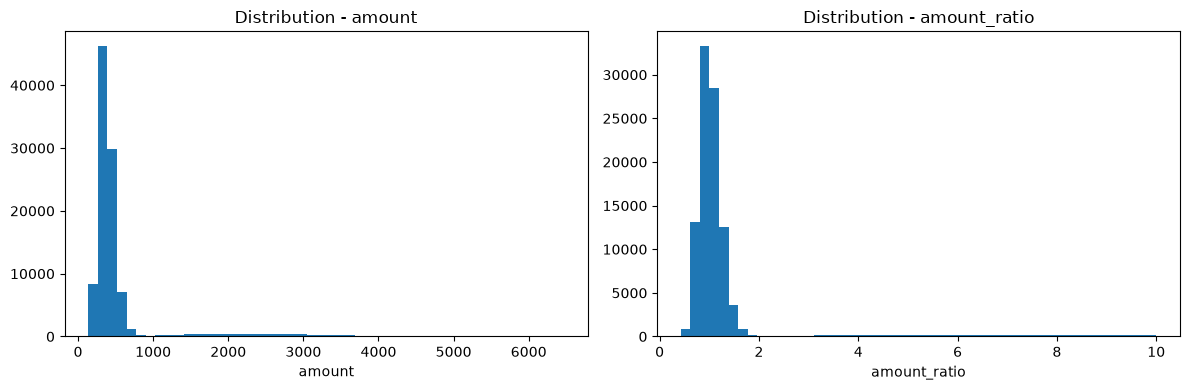

In [33]:
# Point 1 : répartition is_fraud + distribution amount
import matplotlib.pyplot as plt
# -------------------------

print("Répartition is_fraud :")
print(dataset["is_fraud"].value_counts(normalize=True))
print()

print("Statistiques descriptives - amount :")
print(dataset["amount"].describe())
print()

print("Statistiques descriptives - amount_ratio :")
print(dataset["amount_ratio"].describe())
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dataset["amount"], bins=50)
axes[0].set_title("Distribution - amount")
axes[0].set_xlabel("amount")

axes[1].hist(dataset["amount_ratio"], bins=50)
axes[1].set_title("Distribution - amount_ratio")
axes[1].set_xlabel("amount_ratio")

plt.tight_layout()
plt.savefig("dataset/amount_distribution.png")
plt.show()

Moyenne des features binaires par classe :
          device_changed  payment_method_changed  city_changed  \
is_fraud                                                         
0               0.148195                0.199708      0.100343   
1               0.701776                0.601897      0.643664   

          country_changed  out_hours  
is_fraud                              
0                0.101195   0.148784  
1                0.651533   0.603511  

amount_ratio moyen par classe :
            count      mean       std       min       25%       50%       75%  \
is_fraud                                                                        
0         95044.0  1.291435  1.287694  0.434386  0.881542  1.013454  1.172939   
1          4956.0  3.758713  3.072661  0.430250  0.998947  3.014583  6.515205   

               max  
is_fraud            
0         9.999170  
1         9.999968  



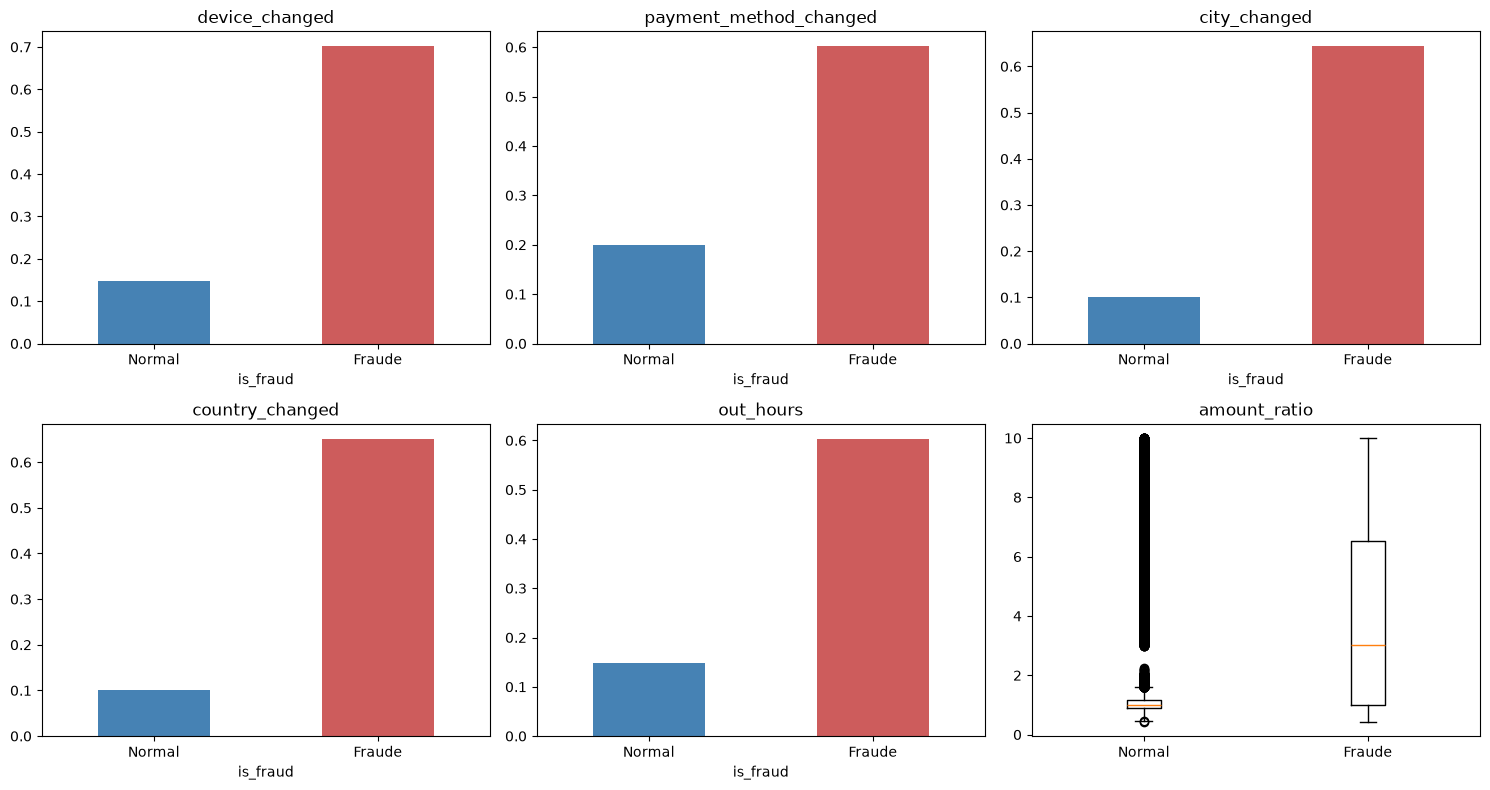

In [34]:
# Point 3 : comparaison des features fraude vs non-fraude
# -------------------------

binary_features = [
    "device_changed",
    "payment_method_changed",
    "city_changed",
    "country_changed",
    "out_hours",
]

print("Moyenne des features binaires par classe :")
print(dataset.groupby("is_fraud")[binary_features].mean())
print()

print("amount_ratio moyen par classe :")
print(dataset.groupby("is_fraud")["amount_ratio"].describe())
print()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(binary_features):
    dataset.groupby("is_fraud")[feature].mean().plot(
        kind="bar", ax=axes[i], color=["steelblue", "indianred"]
    )
    axes[i].set_title(feature)
    axes[i].set_xticklabels(["Normal", "Fraude"], rotation=0)

axes[5].boxplot(
    [
        dataset[dataset["is_fraud"] == 0]["amount_ratio"],
        dataset[dataset["is_fraud"] == 1]["amount_ratio"],
    ],
    tick_labels=["Normal", "Fraude"],
)
axes[5].set_title("amount_ratio")

plt.tight_layout()
plt.savefig("dataset/fraud_vs_normal_comparison.png")
plt.show()




## 2. Machine Learning Section

### 2.1 Dataset Preparation (features / target, train-test split)

In [35]:
# Préparation du dataset
excluded_columns = ['customer_id', 'transaction_id', 'card_id', 'city_changed', 'country_changed', 'city_changed', 'payment_method_changed', 'amount_abnormal', 'out_hours', 'is_fraud']
X = dataset.drop(columns=excluded_columns)
y = dataset["is_fraud"]

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=42, stratify=y)

In [37]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

is_fraud
0    0.950438
1    0.049563
Name: proportion, dtype: float64
is_fraud
0    0.95045
1    0.04955
Name: proportion, dtype: float64


In [38]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 80000 entries, 46309 to 61346
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   amount                80000 non-null  float64
 1   city                  80000 non-null  str    
 2   country               80000 non-null  str    
 3   timestamp             80000 non-null  str    
 4   payment_method        80000 non-null  str    
 5   device_type           80000 non-null  str    
 6   amount_ratio          80000 non-null  float64
 7   device_changed        80000 non-null  int64  
 8   usual_device          80000 non-null  str    
 9   usual_city            80000 non-null  str    
 10  usual_country         80000 non-null  str    
 11  usual_payment_method  80000 non-null  str    
dtypes: float64(2), int64(1), str(9)
memory usage: 7.9 MB


### 2.2 Feature Engineering (timestamp, categorical variable encoding)

In [39]:
# timestamp preprocessing
dataset["timestamp"] = pd.to_datetime(dataset["timestamp"])
dataset["year"] = dataset["timestamp"].dt.year
dataset['month'] = dataset['timestamp'].dt.month
dataset['day'] = dataset['timestamp'].dt.day
dataset['hour'] = dataset['timestamp'].dt.hour

dataset.drop('timestamp', axis=1, inplace=True)

In [40]:
# features engineering
from sklearn.preprocessing import LabelEncoder

label_encoders = {}


for col in X_train.select_dtypes(include=['object', 'string']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = X_test[col].astype(str).apply(lambda x: x if x in le.classes_ else le.classes_[0])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le   



### 2.3 Model 1 — Isolation Forest (unsupervised)

In [41]:
from sklearn.metrics import classification_report
from sklearn.ensemble import IsolationForest


import matplotlib.pyplot as plt
X_train_normal = X_train[y_train == 0]

# Entraînement
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

iso_model.fit(X_train_normal)

# Prédiction
y_pred = iso_model.predict(X_test)

# Conversion
# Isolation Forest :
#  1  -> normal
# -1 -> anomalie
# Nous voulons :
# 0 -> non fraude
# 1 -> fraude

y_pred = (y_pred == -1).astype(int)

# Évaluation
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.98      0.94      0.96     19009
           1       0.38      0.66      0.48       991

    accuracy                           0.93     20000
   macro avg       0.68      0.80      0.72     20000
weighted avg       0.95      0.93      0.94     20000



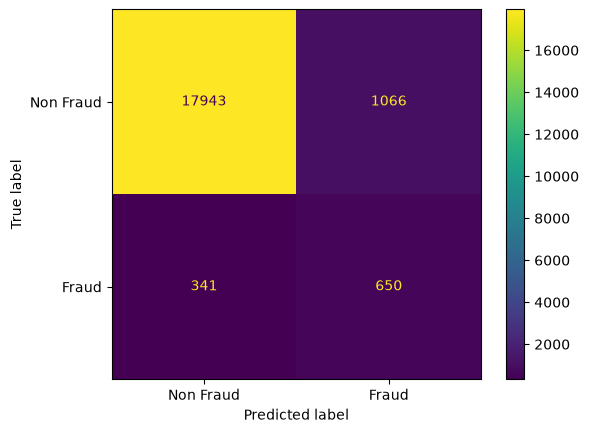

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non Fraud", "Fraud"]
).plot()

plt.show()

### 2.4 Hybrid Approach — Isolation Forest score as a feature

In [43]:
# ajouter le score de isolation forest comme feature 
X_train_scored = X_train.copy()
X_test_scored = X_test.copy()

# Calcul du score d'anomalie pour les données d'entraînement et de test
X_train_scored['iso_anomaly_score'] = iso_model.decision_function(X_train)
X_test_scored['iso_anomaly_score'] = iso_model.decision_function(X_test)

print(X_train_scored['iso_anomaly_score'].describe())
print(X_train_scored.head())

count    80000.000000
mean         0.090758
std          0.057312
min         -0.156435
25%          0.064235
50%          0.105953
75%          0.130898
max          0.178377
Name: iso_anomaly_score, dtype: float64
           amount  city  country  timestamp  payment_method  device_type  \
46309  459.946671    15       10      31037               3            1   
26318  339.716644     5       10      20444               3            1   
58332  451.488933     8       10      37457               1            0   
83218  325.738308     3       10      33103               0            0   
31772  338.938433    19       10         58               3            2   

       amount_ratio  device_changed  usual_device  usual_city  usual_country  \
46309      1.146033               0             1          15              0   
26318      0.811994               1             2          24              0   
58332      0.861321               0             0           8              0   
83218  

### 2.5 Model 2 — XGBoost (with hybrid feature)

In [44]:
from xgboost import XGBClassifier

# calcul du poids sur y_train uniquement
compte = y_train.value_counts()
poids = compte[0] / compte[1]
print(f"scale_pos_weight : {poids:.2f}")

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    scale_pos_weight=poids
)
model.fit(X_train_scored, y_train)

y_proba = model.predict_proba(X_test_scored)[:, 1]
y_preds = model.predict(X_test_scored)

scale_pos_weight : 19.18


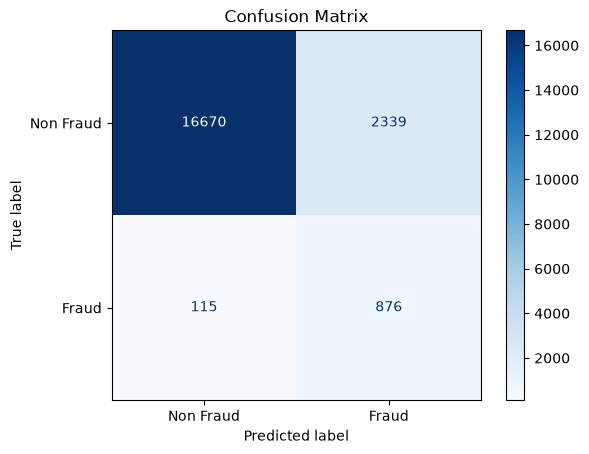

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non Fraud", "Fraud"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

### 2.6 Decision Threshold Optimization

In [46]:
y_proba = model.predict_proba(X_test_scored)[:, 1]
print(y_proba[:5])


[0.5618031  0.03362764 0.03244092 0.0116369  0.97619903]


In [47]:
# determination du seuil de décision
y_test.sum()


np.int64(991)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4176\3514151971.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


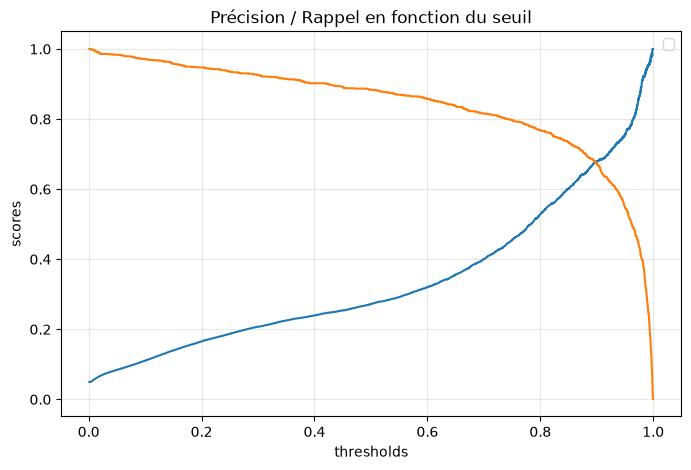

In [48]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1])
plt.plot(thresholds, recall[:-1])
plt.xlabel("thresholds")
plt.ylabel("scores")
plt.legend()
plt.title("Précision / Rappel en fonction du seuil")
plt.grid(alpha=0.3)
plt.show()

In [49]:
import numpy as np

rappel_cible = 0.95
indices_valides = np.where(recall[:-1] >= rappel_cible)[0]
seuil_choisi = thresholds[indices_valides[-1]]  # le seuil le plus haut qui respecte encore le rappel cible

print(f"Seuil choisi : {seuil_choisi:.4f}")
print(f"Précision à ce seuil : {precision[indices_valides[-1]]:.4f}")
print(f"Rappel à ce seuil : {recall[indices_valides[-1]]:.4f}")

Seuil choisi : 0.1712
Précision à ce seuil : 0.1510
Rappel à ce seuil : 0.9506


### 2.7 Final Model — Optimized Threshold (target recall = 95%)

scale_pos_weight : 19.18
              precision    recall  f1-score   support

           0       1.00      0.77      0.87     19009
           1       0.17      0.94      0.29       991

    accuracy                           0.78     20000
   macro avg       0.59      0.86      0.58     20000
weighted avg       0.96      0.78      0.84     20000

[[14591  4418]
 [   57   934]]


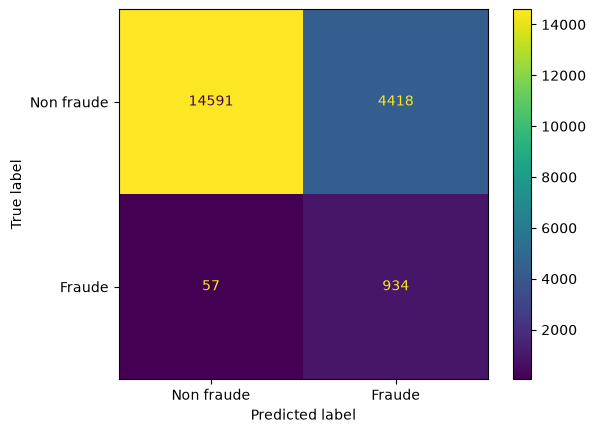

In [50]:
from xgboost import XGBClassifier

# calcul du poids sur y_train uniquement
compte = y_train.value_counts()
poids = compte[0] / compte[1]
print(f"scale_pos_weight : {poids:.2f}")

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    scale_pos_weight=poids
)
model.fit(X_train_scored, y_train)

y_proba = model.predict_proba(X_test_scored)[:, 1]

# ============================================
# Application du seuil optimisé (au lieu de model.predict() qui utilise 0.5)
# ============================================

seuil_choisi = 0.2208  # récupéré depuis ton analyse précision/rappel

y_preds = (y_proba > seuil_choisi).astype(int)

# Évaluation avec ce nouveau seuil
print(classification_report(y_test, y_preds))

cm = confusion_matrix(y_test, y_preds)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non fraude', 'Fraude'])
disp.plot()
plt.show()

In [51]:
#import pandas as pd

#results = pd.DataFrame({
    #"Isolation Forest": {"TN": ..., "FP": ..., "FN": ..., "TP": ..., "Recall": ..., "Precision": ..., "F1": ...},
    #"XGBoost baseline": {...},
    #"XGBoost + hybrid feature": {...},
    #"XGBoost + optimized threshold": {...},})
#results

# Saving the final trained model

In [52]:
import joblib

joblib.dump(model, "models/xgboost_model.pkl")
joblib.dump(iso_model, "models/isolation_forest.pkl")   
joblib.dump(label_encoders, "models/label_encoders.pkl") # dict des LabelEncoder par colonne
joblib.dump(seuil_choisi, "models/threshold.pkl")
joblib.dump(list(X_train_scored.columns), "models/feature_columns.pkl")  # ordre des colonnes !

['models/feature_columns.pkl']

## 3. Conclusion

- **Isolation Forest** (unsupervised): lower recall, serves as a generic anomaly detector.
- **XGBoost + hybrid feature**: better overall performance thanks to the added anomaly signal.
- **Optimized threshold (0.22, target recall 95%)**: strongly reduces false negatives (missed fraud), at the cost of more false positives — a justified trade-off since alerts are automatically verified downstream by an LLM agent, without direct human intervention.
- **Selected model**: hybrid XGBoost with adjusted threshold, to maximize detection of real fraud cases.